# Transient Climate Response to Emissions (TCRE)

This notebook computes a process-based estimate of TCRE by combining posteriors for the land and ocean carbon-carbon effect $\beta$ and the land and ocean carbon-climate effect $\gamma$.

## Definition of TCRE

$$\text{TCRE} = \alpha \cdot \text{AF}, \qquad \text{AF} = \frac{1}{k + \beta + \alpha\,\gamma}$$

| Symbol | Description | Units |
|--------|-------------|-------|
| $\alpha$ | Transient climate sensitivity ($\approx$ TCR / 280 ppm) | K ppm⁻¹ |
| $\beta = \beta_L + \beta_O$ | Carbon-concentration feedback (land + ocean) | PgC ppm⁻¹ |
| $\gamma = \gamma_L + \gamma_O$ | Carbon-climate feedback (land + ocean) | PgC K⁻¹ |
| $k = 2.12$ | CO₂-to-carbon conversion | PgC ppm⁻¹ |

All parameters are evaluated at 2×CO₂ (CO₂ doubled from pre-industrial 280 ppm to 560 ppm).

## Structure

Each component is estimated with a dedicated Bayesian model.
Default prior hyperparameters live in `config/priors.py` 
Model construction is in `bayes/model_builders.py`.

| Component | Model type | Prior file key |
|-----------|-----------|----------------|
| $\gamma_L$ | Additive process model (permafrost, fire, veg, nitrogen) | `priors.gamma_land` |
| $\beta_L$ | Multiplicative process model (nitrogen, fire, veg) | `priors.beta_land` |
| $\beta_O$ | Emergent constraint via AMOC, SSS, CUC | `priors.beta_ocean` |
| $\gamma_O$ | Correlated random-effects model | `priors.gamma_ocean` |

In [1]:
import pymc as pm
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import pandas as pd
import pprint

import sys
from pathlib import Path

root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from bayes import DATA_DIR
from bayes import model_builders
from config import priors
from utils import data_utils

## Data

Land and ocean data come from different sources and cover partially different model sets:

- **Land** (13 CMIP6 models): `TCREsource_betagamma.csv` + `lookup_table.nc`
- **Ocean** (13 models in Terhaar pape, 11 overlap with land): `beta_gamma_terhaar.nc` + `Terhaar.txt`

 <b> CHRIS: we need a spreadsheet with all $\beta$ and $\gamma$ calculated in the same way. </b>

In [2]:
# Land data — 13 CMIP6 models, same ordering as lookup_table.nc
df = pd.read_csv(DATA_DIR / "TCREsource_betagamma.csv")
mask = df["source"].isin(["CMIP6", "CMIP6+"])
models_land = df.loc[mask, "model"].values

cmip_beta_land  = xr.DataArray(df.loc[mask, "beta_L_2xCO2"].values,
                               coords={"model": models_land}, dims="model")
cmip_gamma_land = xr.DataArray(df.loc[mask, "gamma_L_2xCO2"].values,
                               coords={"model": models_land}, dims="model")

lookup_table = xr.open_dataarray(DATA_DIR / "lookup_table.nc")


In [3]:
# Ocean data — 13 models provided by Terhaar et al
terhaar_bg = xr.load_dataset(DATA_DIR / "beta_gamma_terhaar.nc", decode_times=False)
cmip_beta_ocean  = terhaar_bg.beta.isel(time=69)   # 2xCO2
cmip_gamma_ocean = terhaar_bg.gamma.isel(time=69)  # 2xCO2

# Emergent-constraint observables for the beta_O model
ec_ds  = data_utils.load_ocean_ec_predictors()
obs    = data_utils.load_ocean_ec_obs()
ec_std = data_utils.standardize_ocean_ec(ec_ds, obs)

print("Ocean models:", cmip_beta_ocean.model.values)

Ocean models: ['ACCESS-ESM1-5' 'CanESM5' 'CESM2' 'CMCC-ESM2' 'EC-Earth3-CC' 'GFDL-ESM4'
 'IPSL-CM6A-LR' 'MIROC-ES2L' 'MPI-ESM1-2-LR' 'MRI-ESM2-0' 'NorESM2-LM'
 'UKESM1-0-LL' 'GISS-E2-1-G']


## CMIP6 reference distribution

Choose the the 11 models common to both land and ocean datasets. Individual model $\alpha$ values (TCR / 280 ppm) are taken from Chris Jones' spreadsheet. **NEED THORSTEN'S ESTIMATES**

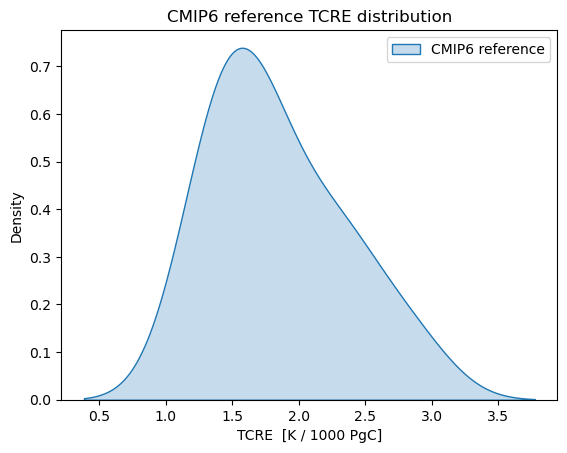

In [4]:
k = priors.K  # 2.12 PgC ppm^-1

# 11 models common to land and ocean
common = data_utils.load_carbon_parameters()
beta_cmip_ref  = common.beta_land.values  + common.beta_ocean.values
gamma_cmip_ref = common.gamma_land.values + common.gamma_ocean.values

# Individual model alpha = TCR / 280 ppm (K ppm^-1), ordered to match common models
alpha_cmip = np.array([0.0074, 0.0059, 0.0094, 0.0078, 0.0064,
                       0.0087, 0.0052, 0.0063, 0.0054, 0.0050, 0.0088])

AF_cmip   = 1 / (k + beta_cmip_ref + alpha_cmip * gamma_cmip_ref)
TCRE_cmip = alpha_cmip * AF_cmip

fig, ax = plt.subplots()
sns.kdeplot(1e3 * TCRE_cmip, label="CMIP6 reference", fill=True, ax=ax)
ax.set_xlabel("TCRE  [K / 1000 PgC]")
ax.set_title("CMIP6 reference TCRE distribution")
ax.legend()

---
## Component 1: Land carbon-climate feedback ($\gamma_L$)

$\gamma_L$ quantifies carbon released from the terrestrial biosphere per degree of warming (PgC K⁻¹). A more negative $\gamma_L$ means stronger land carbon release under warming, which raises TCRE.

**Model:** additive process model — a baseline $\gamma_L$ plus additive contributions from four land processes:

$$\gamma_{L,m} = \gamma_L^\text{base} + \sum_p (\delta_p + \varepsilon_{pm}) \cdot L_{pm}$$

where the lookup table $L_{pm} \in \{0,1\}$ flags whether CMIP6 model $m$ includes process $p$, and $\varepsilon_{pm} \sim \mathcal{N}(0, \sigma_p)$ is a model-level random effect (basically, how does the model process differ from the real-world process?)

**Default priors** (`config/priors.gamma_land`):

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| $\gamma_L^\text{base}$ | Normal(0, 100) | Uninformative |
| $\delta_\text{permafrost}$ | −LogNormal(log(30_, 1) | Constrained negative: thaw always releases carbon |
| $\delta_\text{nitrogen}$ | LogNormal(log(10), 1) | Constrained positive: N availability sequesters carbon |
| $\delta_\text{fire}$ | Normal(0, 10) | Uncertain sign |
| $\delta_\text{veg}$ | Normal(0, 10) | Uncertain sign |

Model-level random-effect σ: permafrost = 100, fire = 30, veg = 50, nitrogen = 5 PgC K⁻¹.  
Likelihood noise σ_obs = 5 PgC K⁻¹.

**The end result will depend heavily on the permafrost prior**

In [5]:
gamma_land_model = model_builders.build_gamma_land_model(
    cmip_gamma_land, lookup_table, priors.gamma_land
)
with gamma_land_model:
    gamma_land = pm.sample(target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [gamma_land_unscaled, sigma_struct, rho, bias_m_raw, bias_common_raw, nitrogen, negative_permafrost, fire, veg, eps_add]


/Users/katemarvel/miniforge3/envs/tcre/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 35 seconds.


### An example of changing the priors
What if we were certain that permafrost did nothing?  We could pass this to the model in the form of a confident prior on $\delta_{permafrost}$.  

In [6]:
priors_no_permafrost = priors.gamma_land
priors_no_permafrost["delta"]["permafrost"]={'dist': 'Normal', 'mu': 0, 'sigma': 1.e-6}
gamma_land_model_NOPF = model_builders.build_gamma_land_model(
    cmip_gamma_land, lookup_table, priors_no_permafrost
)
with gamma_land_model_NOPF:
    gamma_land_NOPF = pm.sample(target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [gamma_land_unscaled, sigma_struct, rho, bias_m_raw, bias_common_raw, nitrogen, permafrost, fire, veg, eps_add]


/Users/katemarvel/miniforge3/envs/tcre/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.


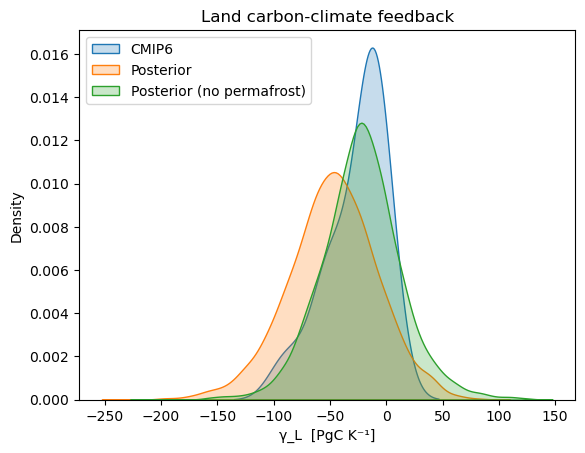

In [7]:
fig, ax = plt.subplots()
sns.kdeplot(cmip_gamma_land.values, label="CMIP6", fill=True, ax=ax)
sns.kdeplot(gamma_land.posterior.gamma_land.values.flatten(), label="Posterior", fill=True, ax=ax)
sns.kdeplot(gamma_land_NOPF.posterior.gamma_land.values.flatten(), label="Posterior (no permafrost)", fill=True, ax=ax)
ax.set_xlabel("γ_L  [PgC K⁻¹]")
ax.set_title("Land carbon-climate feedback")
ax.legend()

Our prior knowledge of permafrost really matters!  By itself, the data won't give us the information we need because the CMIP models don't explicitly contain permafrost.  If we get more data on $\delta_{permafrost}$, this will constrain our understanding of $\gamma_{L}$

---
## Component 2: Land carbon-concentration feedback (β_L)

β_L quantifies additional carbon sequestered by the terrestrial biosphere per ppm of atmospheric CO₂ (PgC ppm⁻¹). Larger β_L means a stronger land sink, which lowers TCRE.

**Model:** multiplicative process model — a baseline β_L adjusted by process-level factors:

$$\beta_{L,m} = \beta_L^\text{base} \cdot \prod_p \eta_p^{L_{pm}}, \qquad \eta_p = \exp(\log\eta_p)$$

**Default priors** (`config/priors.beta_land`):

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| $\beta_L^\text{base}$ | LogNormal(0, 0.5) | Weakly informative; enforces positivity |
| $\log\eta_\text{nitrogen}$ | Normal(−0.2, 0.3) | N-limitation reduces sink (η < 1) |
| $\log\eta_\text{fire}$ | Normal(0, 0.3) | Uncertain |
| $\log\eta_\text{veg}$ | Normal(0, 0.3) | Uncertain |

Likelihood noise σ_obs = 0.1 PgC ppm⁻¹.

**Additional constraint:** paired nitrogen-experiment observations (η_nitrogen = 0.69 from ACCESS-ESM, 0.77 from UKESM1) are added as pseudo-observations with σ = 0.1.

<b>Need to add other processes </b>

In [8]:
beta_land_model = model_builders.build_beta_land_model(
    cmip_beta_land, lookup_table, priors.beta_land
)
with beta_land_model:
    beta_land = pm.sample(target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_land_unscaled, sigma_struct, rho, bias_m_raw, bias_common_raw, log_eta_offset, eps_mult]


/Users/katemarvel/miniforge3/envs/tcre/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


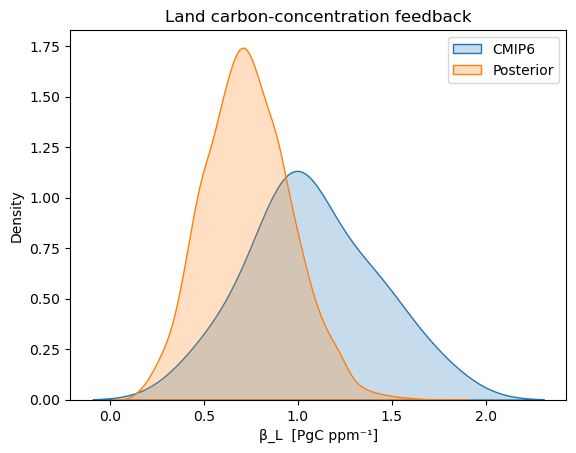

In [9]:
fig, ax = plt.subplots()
sns.kdeplot(cmip_beta_land.values, label="CMIP6", fill=True, ax=ax)
sns.kdeplot(beta_land.posterior.beta_land.values.flatten(), label="Posterior", fill=True, ax=ax)
ax.set_xlabel("β_L  [PgC ppm⁻¹]")
ax.set_title("Land carbon-concentration feedback")
ax.legend()

---
## Components 3 & 4: Ocean feedbacks — joint emergent constraint

β_O and γ_O are constrained **jointly** by the same three observable ocean
circulation metrics (Terhaar et al.), exploiting the fact that both feedbacks
are correlated with AMOC strength, sea-surface salinity (SSS), and chemical
uptake capacity (CUC) across the CMIP6 ensemble.

**Model:** multivariate regression linking both log(β_O) and standardised γ_O
to the observables jointly, with a 3×2 slope matrix **b**:

$$\mathcal{O}^m \sim \mathcal{MN}\!\left(a + B\,x^m,\,\Sigma\right),
\qquad x^m = \bigl[\log\beta_O^m,\;\tilde{\gamma}_O^m\bigr]^\top$$

where $\tilde{\gamma}_O^m = (\gamma_O^m - \bar{\gamma}_O^\text{CMIP}) / \sigma_\text{CMIP}$.
Conditioning on real-world observations simultaneously constrains both posteriors
and preserves their joint correlation.

| Observable | Observed value | σ |
|------------|---------------|---|
| AMOC strength | 17.02 | 0.35 |
| Sea Surface Salinity (SSS) | 34.04 | 0.04 |
| Chemical uptake capacity | 0.546 | 0.003 |

**Default priors** (`config/priors.joint_ocean`):

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| $\theta = \log\beta_O$ | Normal(0, 0.5) | Weakly informative on log scale |
| $\tilde{\gamma}_O$ | Normal(0, 1) | Within ~1 CMIP std of ensemble mean |
| Intercepts $a$ | Normal(0, 10) ×3 | Broad prior on emergent relationship |
| Slopes $B$ | Normal(0, 10) ×(3×2) | Broad prior on emergent relationship |
| Covariance Σ | LKJCholeskyCov(η=2, σ~HalfNormal(5)) | Cross-observable correlations |

In [10]:
pprint.pprint(priors.joint_ocean)

{'gamma_s_true': {'mu': 0.0, 'sigma': 1.0},
 'lkj': {'eta': 2.0, 'sd_sigma': 5.0},
 'regression': {'mu': 0.0, 'sigma': 10.0},
 'theta': {'mu': 0.0, 'sigma': 0.5}}


In [11]:
joint_ocean_model = model_builders.build_joint_ocean_model(
    cmip_beta_ocean,
    cmip_gamma_ocean,
    ec_std["O_m"],
    ec_std["O_obs"],
    ec_std["O_obs_unc"],
    priors.joint_ocean,
)
with joint_ocean_model:
    ocean = pm.sample(target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, chol_cov, theta, gamma_s_true, O_true]


/Users/katemarvel/miniforge3/envs/tcre/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


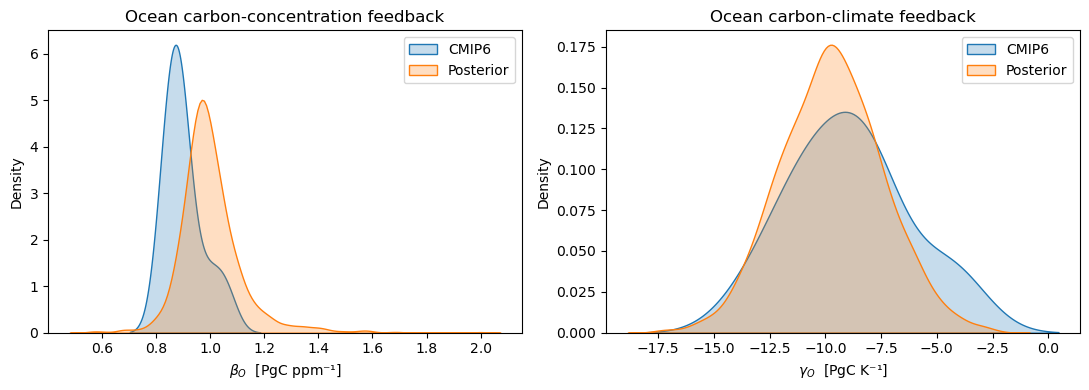

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
sns.kdeplot(cmip_beta_ocean.values, label="CMIP6", fill=True, ax=ax)
sns.kdeplot(ocean.posterior.beta_ocean.values.flatten(), label="Posterior", fill=True, ax=ax)
ax.set_xlabel(r"$\beta_O$  [PgC ppm⁻¹]")
ax.set_title("Ocean carbon-concentration feedback")
ax.legend()

ax = axes[1]
sns.kdeplot(cmip_gamma_ocean.values, label="CMIP6", fill=True, ax=ax)
sns.kdeplot(ocean.posterior.gamma_ocean.values.flatten(), label="Posterior", fill=True, ax=ax)
ax.set_xlabel(r"$\gamma_O$  [PgC K⁻¹]")
ax.set_title("Ocean carbon-climate feedback")
ax.legend()

plt.tight_layout()

*γ_O is constrained jointly with β_O in the section above.*

---
## Combining components

Total feedbacks are sums of land and ocean posteriors:

$$\beta = \beta_L + \beta_O, \qquad \gamma = \gamma_L + \gamma_O$$

We add posterior samples directly.  The land components (β_L, γ_L) are
approximately independent of the ocean components conditioned on the CMIP6
data, since they were fit to different observational targets.  Within the ocean,
β_O and γ_O are drawn from the same joint trace, so their posterior correlation
(induced by the shared emergent-constraint observables) is preserved.

In [13]:
beta_samples  = (beta_land.posterior.beta_land.values.flatten() +
                 ocean.posterior.beta_ocean.values.flatten())

gamma_samples = (gamma_land.posterior.gamma_land.values.flatten() +
                 ocean.posterior.gamma_ocean.values.flatten())

---
## Prior on α (transient climate sensitivity)

α converts atmospheric CO₂ change into global temperature change (K ppm⁻¹). 

$$\text{TCR} \sim \mathcal{N}(\mu_\text{TCR},\, \sigma_\text{TCR}) \text{ K}, \qquad \alpha = \frac{\text{TCR}}{p_{\text{CO}_2}^\text{ref}}$$
<b> Right now I just use the values from Chris table: wait for Thorsten group</b>
Default values from `config/priors.alpha`:

| Parameter | Value |
|-----------|-------|
| TCR_mu | 1.7 K |
| TCR_sigma | 0.36 K |
| pco2_ref | 280 ppm |



{'TCR_mu': 1.7, 'TCR_sigma': 0.36, 'pco2_ref': 280.0}


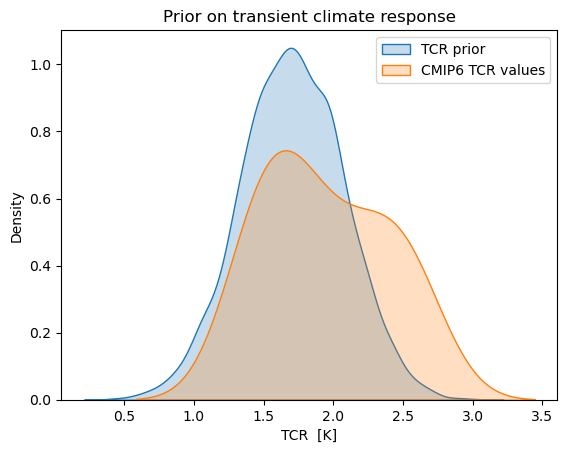

In [14]:
pprint.pprint(priors.alpha)

n_samples     = len(beta_samples)
TCR_samples   = np.random.normal(priors.alpha["TCR_mu"], priors.alpha["TCR_sigma"], n_samples)
alpha_samples = TCR_samples / priors.alpha["pco2_ref"]  # K ppm^-1

fig, ax = plt.subplots()
sns.kdeplot(TCR_samples, label="TCR prior", fill=True, ax=ax)
sns.kdeplot(alpha_cmip * priors.alpha["pco2_ref"], label="CMIP6 TCR values", fill=True, ax=ax)
ax.set_xlabel("TCR  [K]")
ax.set_title("Prior on transient climate response")
ax.legend()

---
## TCRE posterior

With posterior samples of β, γ, and α in hand:

$$\text{AF} = \frac{1}{k + \beta + \alpha\,\gamma}, \qquad \text{TCRE} = \alpha \cdot \text{AF}$$

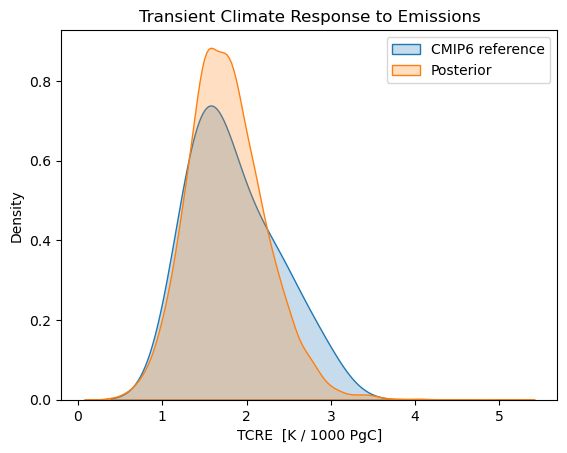

In [15]:
AF = 1.0 / (k + beta_samples + alpha_samples * gamma_samples)
TCRE_posterior = 1e3 * alpha_samples * AF  # K / (1000 PgC)

fig, ax = plt.subplots()
sns.kdeplot(1e3 * TCRE_cmip, label="CMIP6 reference", fill=True, ax=ax)
sns.kdeplot(TCRE_posterior,  label="Posterior",        fill=True, ax=ax)
ax.set_xlabel("TCRE  [K / 1000 PgC]")
ax.set_title("Transient Climate Response to Emissions")
ax.legend()

In [16]:
hdi_95 = az.hdi(TCRE_posterior, hdi_prob=0.95)
print(f"TCRE posterior mean:   {TCRE_posterior.mean():.3f} K / 1000 PgC")
print(f"TCRE 95% HDI:          [{hdi_95[0]:.3f}, {hdi_95[1]:.3f}] K / 1000 PgC")

TCRE posterior mean:   1.766 K / 1000 PgC
TCRE 95% HDI:          [0.943, 2.765] K / 1000 PgC
